In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
print("Image shape:", x_train[0].shape)
print("Pixel minimum:", x_train.min())
print("Pixel maximum:", x_train.max())

print("First 10 labels:")
print(y_train[:10])

Image shape: (28, 28)
Pixel minimum: 0
Pixel maximum: 255
First 10 labels:
[5 0 4 1 9 2 1 3 1 4]


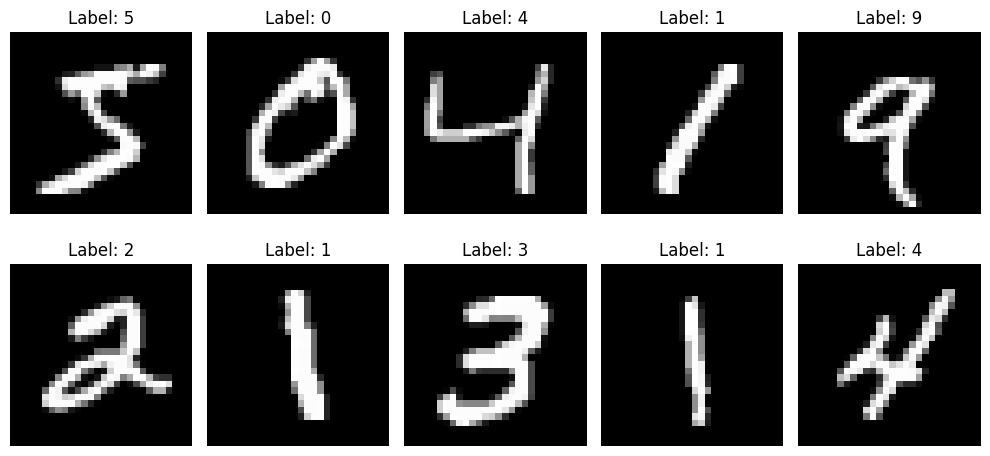

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9259 - loss: 0.2546 - val_accuracy: 0.9667 - val_loss: 0.1164
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9688 - loss: 0.1043 - val_accuracy: 0.9742 - val_loss: 0.0895
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9777 - loss: 0.0716 - val_accuracy: 0.9730 - val_loss: 0.0857
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9823 - loss: 0.0542 - val_accuracy: 0.9783 - val_loss: 0.0816
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9790 - val_loss: 0.0843
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9879 - loss: 0.0355 - val_accuracy: 0.9778 - val_loss: 0.0813
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9897 - loss: 0.0300 - val_accuracy: 0.9792 - val_loss: 0.0777
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9927 - loss: 0.0221 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.08740263432264328
Test Accuracy: 0.9779000282287598
Test Accuracy (%): 97.79000282287598


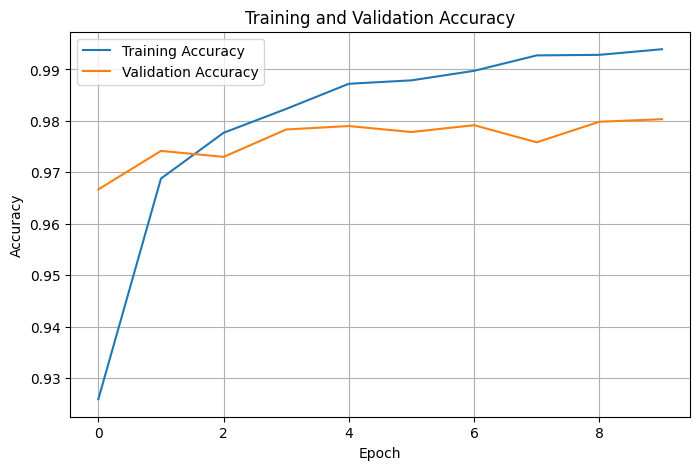

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

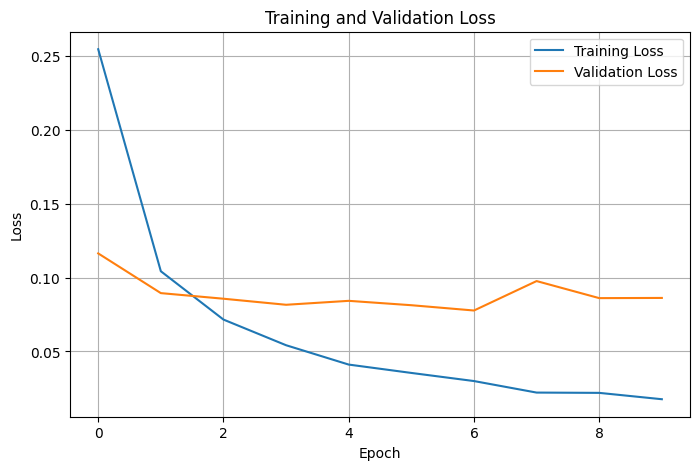

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
predictions = model.predict(x_test[:5], verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

print("Actual Labels:   ", y_test[:5])
print("Predicted Labels:", predicted_labels)

Actual Labels:    [7 2 1 0 4]
Predicted Labels: [7 2 1 0 4]


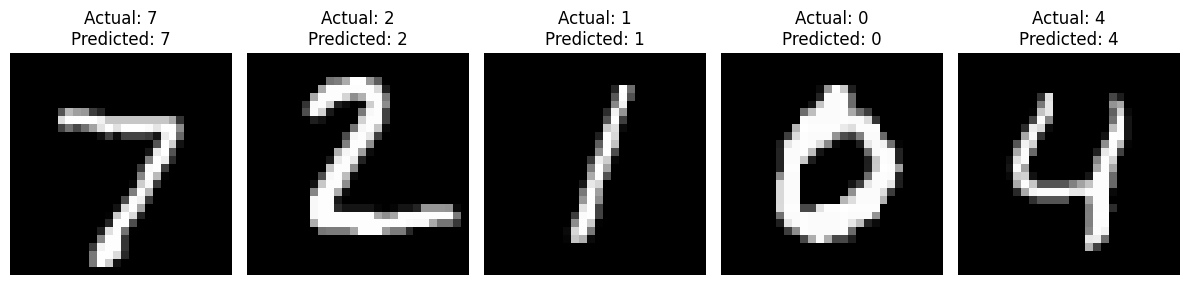

In [ ]:
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(x_test[i], cmap='gray')

    actual = y_test[i]
    predicted = predicted_labels[i]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8937 - loss: 0.3494 - val_accuracy: 0.9658 - val_loss: 0.1073
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9514 - loss: 0.1653 - val_accuracy: 0.9723 - val_loss: 0.0869
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9605 - loss: 0.1307 - val_accuracy: 0.9753 - val_loss: 0.0810
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9669 - loss: 0.1088 - val_accuracy: 0.9785 - val_loss: 0.0729
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0951 - val_accuracy: 0.9773 - val_loss: 0.0768
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0850 - val_accuracy: 0.9785 - val_loss: 0.0740
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9750 - loss: 0.0795 - val_accuracy: 0.9827 - val_loss: 0.0667
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9767 - loss: 0.0722 - 

In [ ]:
exp_loss, exp_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Experimental Test Loss:", exp_loss)
print("Experimental Test Accuracy:", exp_accuracy)
print("Experimental Accuracy (%):", exp_accuracy * 100)

Experimental Test Loss: 0.07067713141441345
Experimental Test Accuracy: 0.9799000024795532
Experimental Accuracy (%): 97.99000024795532


In [ ]:
print("Original Model Accuracy:   ", test_accuracy * 100, "%")
print("Dropout Model Accuracy:    ", exp_accuracy * 100, "%")

Original Model Accuracy:    97.79000282287598 %
Dropout Model Accuracy:     97.99000024795532 %


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Original Model", "Dropout Model"],
    "Test Accuracy": [
        test_accuracy * 100,
        exp_accuracy * 100
    ]
})

comparison

,Model,Test Accuracy
0,Original Model,97.790003
1,Dropout Model,97.990000


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['val_accuracy'],
    label='Original Model'
)

plt.plot(
    experiment_history.history['val_accuracy'],
    label='Dropout Model'
)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid()
plt.show()